# Sensivity Analysis

## 1.1 Operational test with online CMEMS Api dataset





In [1]:
import heco
output_1_1 = heco.run('operational_test_1_1.yaml')
# 50 min if run with cmems live web API
# seconds if use local dataset downloaded from CMEMS (see README.md)

INFO - 2026-07-15T10:11:05Z - Dataset version was not specified, the latest one was selected: "202511"
INFO - 2026-07-15T10:11:05Z - Dataset part was not specified, the first one was selected: "default"
INFO - 2026-07-15T10:11:12Z - Service was not specified, the default one was selected: "arco-geo-series"
INFO - 2026-07-15T10:11:19Z - Dataset version was not specified, the latest one was selected: "202511"
INFO - 2026-07-15T10:11:19Z - Dataset part was not specified, the first one was selected: "default"
INFO - 2026-07-15T10:11:21Z - Service was not specified, the default one was selected: "arco-geo-series"
Access to Cmems data using API successful
Volume per particle considered: 10.0 m3
discrete spill step 0 , release time 2025-03-08 00:00:00
discrete spill step 1 , release time 2025-03-08 01:00:00
discrete spill step 2 , release time 2025-03-08 02:00:00
discrete spill step 3 , release time 2025-03-08 03:00:00
discrete spill step 4 , release time 2025-03-08 04:00:00
discrete spill st

Simulation results saved to op_1_1/heco_results.csv and op_1_1/heco_results.geojson


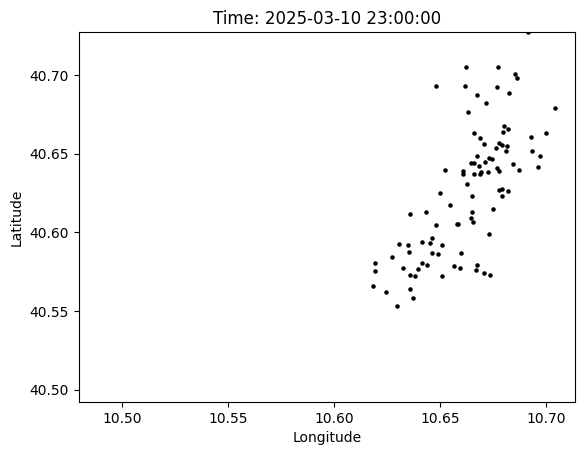

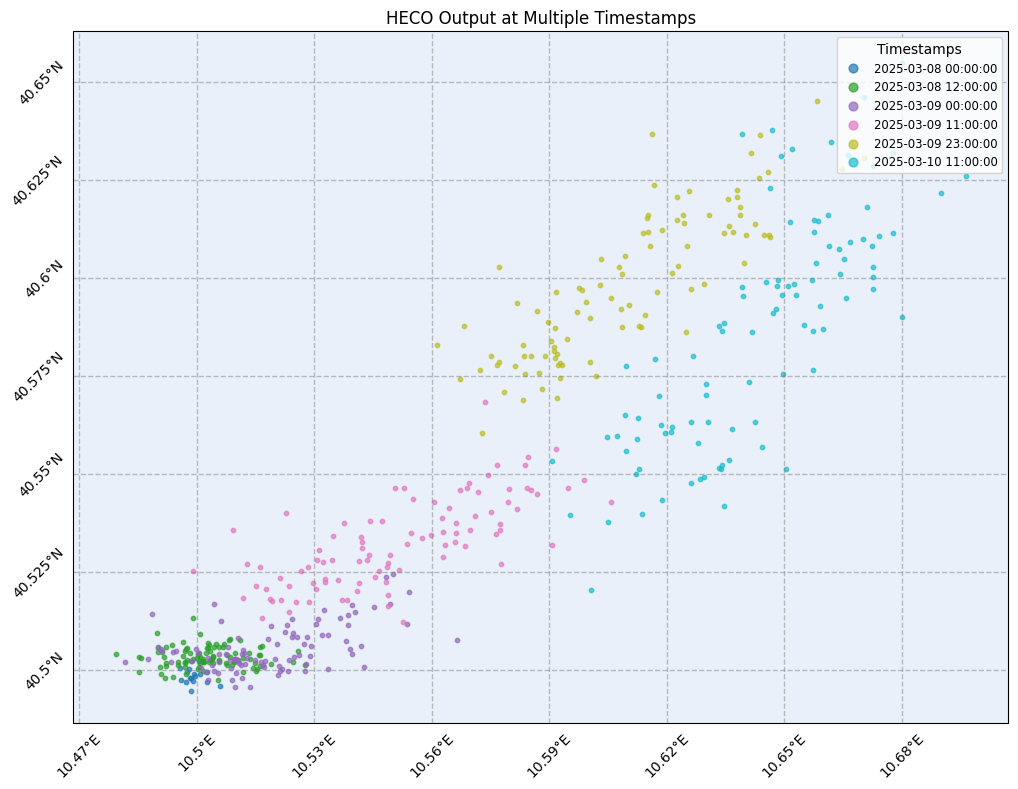

In [2]:
# save result to csv
output_1_1.to_csv('op_1_1/heco_results.csv', index=False)

# Save point to geojson with geopandas
import geopandas as gpd
gdf = gpd.GeoDataFrame(output_1_1, geometry=gpd.points_from_xy(output_1_1.lon, output_1_1.lat))
gdf.crs = "EPSG:4326"
gdf.to_file('op_1_1/heco_results.geojson', driver='GeoJSON')

print('Simulation results saved to op_1_1/heco_results.csv and op_1_1/heco_results.geojson')

heco.create_points_animation('op_1_1/heco_results.geojson','op_1_1/heco_results.gif')
heco.multitimestamp_plot(output_1_1, 6)
# export webmap

heco.create_webmap(
    HECOpoint_output_gdf_path = 'op_1_1/heco_results.geojson',
    EMODnetLayers = True,
    settingsFile_path = 'operational_test_1_1.yaml',
    output_path = 'op_1_1/heco_map.html',
    savepolygons = True
)

## 1.2 Test with offline data


Dataset HECO_TEST.nc opened
Volume per particle considered: 10.0 m3
discrete spill step 0 , release time 2025-03-08 00:00:00
discrete spill step 1 , release time 2025-03-08 01:00:00
discrete spill step 2 , release time 2025-03-08 02:00:00
discrete spill step 3 , release time 2025-03-08 03:00:00
discrete spill step 4 , release time 2025-03-08 04:00:00
discrete spill step 5 , release time 2025-03-08 05:00:00
Simulation results saved to op_1_2/heco_results_1.2.csv and op_1_2/heco_results_1.2.geojson


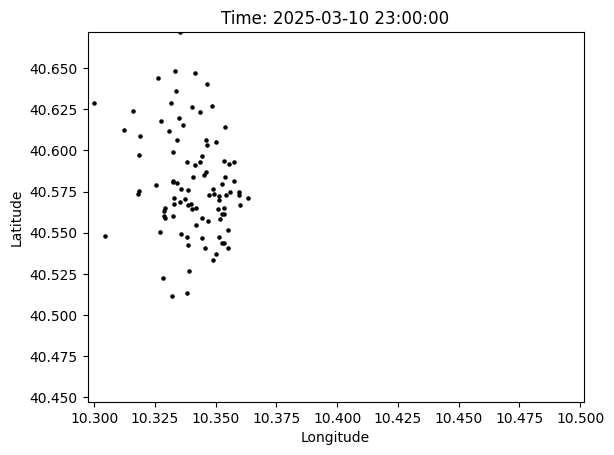

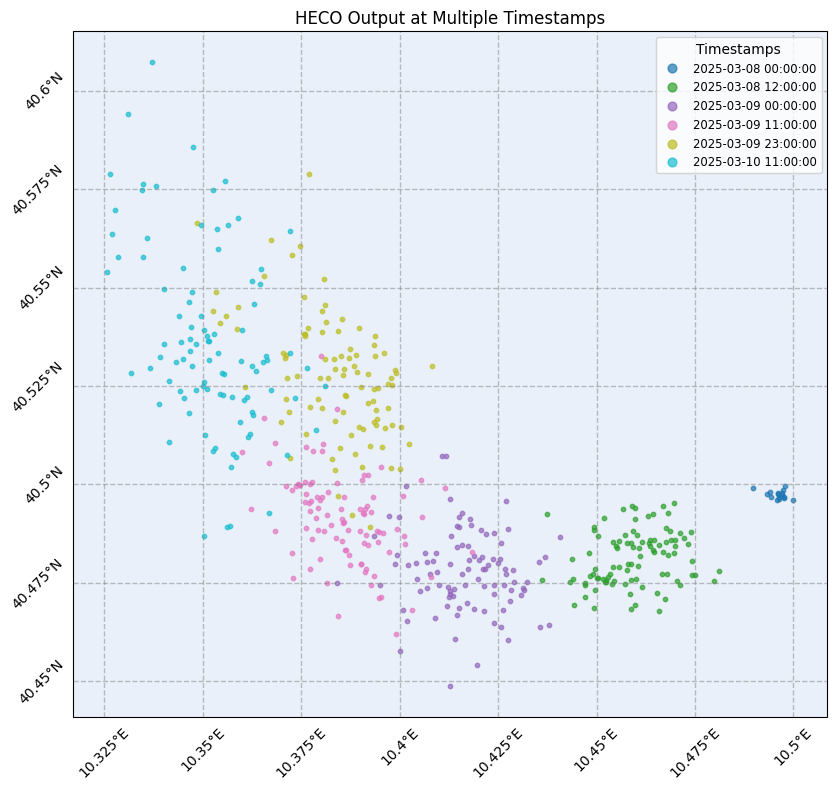

In [2]:
import heco

output_1_2 = heco.run('operational_test_1_2.yaml')

# save result to csv
output_1_2.to_csv('op_1_2/heco_results_1.2.csv', index=False)

# Save point to geojson with geopandas
import geopandas as gpd
gdf = gpd.GeoDataFrame(output_1_2, geometry=gpd.points_from_xy(output_1_2.lon, output_1_2.lat))
gdf.crs = "EPSG:4326"
gdf.to_file('op_1_2/heco_results_1.2.geojson', driver='GeoJSON')

print('Simulation results saved to op_1_2/heco_results_1.2.csv and op_1_2/heco_results_1.2.geojson')

heco.create_points_animation('op_1_2/heco_results_1.2.geojson','op_1_2/heco_results_1.2.gif')
heco.multitimestamp_plot(output_1_2, 6)
# export webmap

heco.create_webmap(
    HECOpoint_output_gdf_path = 'op_1_2/heco_results_1.2.geojson',
    EMODnetLayers = True,
    settingsFile_path = 'operational_test_1_2.yaml',
    output_path = 'op_1_2/heco_map_1.2.html',
    savepolygons = True
)

# 2. Sensivity analysis

## 2.1 Test for location origin perturbation

Model will be executed with 10 different version of the same input parameter, but there are a variation of origin location:

*Master input data:*
```yaml
   input:
    lat0: 40.5
    lon0: 10.5
    
```
perturbated input data:

|test no.|lat0|lon0|
|---|---|---|
|#0|40.5000|10.5000|
|#1|40.4912|10.5045|
|#2|40.5081|10.4967|
|#3|40.4955|10.4921|
|#4|40.5023|10.5088|
|#5|40.4989|10.5012|
|#6|40.5064|10.4905|
|#7|40.4933|10.5091|
|#8|40.5019|10.4944|
|#9|40.5095|10.5056|

In [3]:
import yaml
import os

# The coordinates generated in the previous table
coordinates = [
    (40.5000, 10.5000), # Test #0 (Master)
    (40.4912, 10.5045), # Test #1
    (40.5081, 10.4967), # Test #2
    (40.4955, 10.4921), # Test #3
    (40.5023, 10.5088), # Test #4
    (40.4989, 10.5012), # Test #5
    (40.5064, 10.4905), # Test #6
    (40.4933, 10.5091), # Test #7
    (40.5019, 10.4944), # Test #8
    (40.5095, 10.5056)  # Test #9
]

# The base configuration structure
base_config = {
    'input': {
        'dataset_file_name': 'HECO_TEST.nc',
        'lat0': 40.5,
        'lon0': 10.5,
        'sim_diffusion_coeff': 10.0,
        'sim_duration_h': 72.0,
        'sim_particles': 100.0,
        'sim_timedelta_s': 3600.0,
        'spill_release_duration_h': 6.0,
        'time0': '2025-03-08 00:00:00',
        'volume_spilled_m3': 1000.0
    }
}

# Create a directory to store the generated YAML files
output_dir = "sa_2_1"
os.makedirs(output_dir, exist_ok=True)

# Generate and save the 10 versions
for i, (lat, lon) in enumerate(coordinates):
    # Update the coordinates for the current iteration
    base_config['input']['lat0'] = lat
    base_config['input']['lon0'] = lon
    
    # Define the output file name
    file_name = os.path.join(output_dir, f"sa_2_1_test_{i}.yaml")
    
    # Write the dictionary to a YAML file
    with open(file_name, 'w') as yaml_file:
        yaml.dump(base_config, yaml_file, default_flow_style=False, sort_keys=False)
        
    print(f"Saved: {file_name} -> (lat0: {lat}, lon0: {lon})")

print("\nAll 10 YAML files have been generated successfully.")

Saved: sa_2_1/sa_2_1_test_0.yaml -> (lat0: 40.5, lon0: 10.5)
Saved: sa_2_1/sa_2_1_test_1.yaml -> (lat0: 40.4912, lon0: 10.5045)
Saved: sa_2_1/sa_2_1_test_2.yaml -> (lat0: 40.5081, lon0: 10.4967)
Saved: sa_2_1/sa_2_1_test_3.yaml -> (lat0: 40.4955, lon0: 10.4921)
Saved: sa_2_1/sa_2_1_test_4.yaml -> (lat0: 40.5023, lon0: 10.5088)
Saved: sa_2_1/sa_2_1_test_5.yaml -> (lat0: 40.4989, lon0: 10.5012)
Saved: sa_2_1/sa_2_1_test_6.yaml -> (lat0: 40.5064, lon0: 10.4905)
Saved: sa_2_1/sa_2_1_test_7.yaml -> (lat0: 40.4933, lon0: 10.5091)
Saved: sa_2_1/sa_2_1_test_8.yaml -> (lat0: 40.5019, lon0: 10.4944)
Saved: sa_2_1/sa_2_1_test_9.yaml -> (lat0: 40.5095, lon0: 10.5056)

All 10 YAML files have been generated successfully.


Dataset HECO_TEST.nc opened
Volume per particle considered: 10.0 m3
discrete spill step 0 , release time 2025-03-08 00:00:00
discrete spill step 1 , release time 2025-03-08 01:00:00
discrete spill step 2 , release time 2025-03-08 02:00:00
discrete spill step 3 , release time 2025-03-08 03:00:00
discrete spill step 4 , release time 2025-03-08 04:00:00
discrete spill step 5 , release time 2025-03-08 05:00:00
Simulation results for test 0 saved to sa_2_1/heco_results_test_0.csv and sa_2_1/heco_results_test_0.geojson


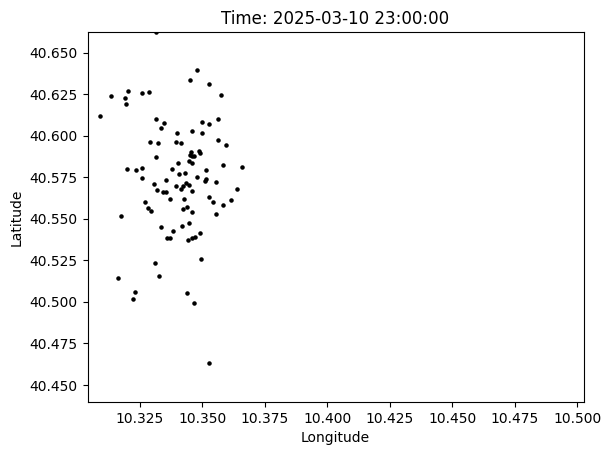

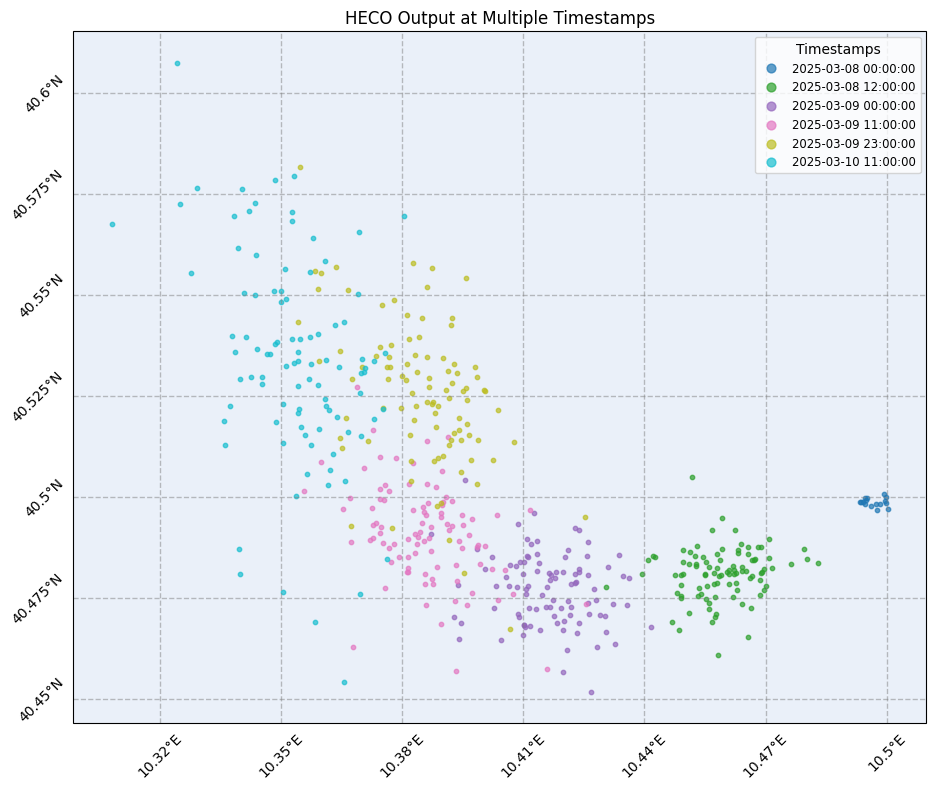

Dataset HECO_TEST.nc opened
Volume per particle considered: 10.0 m3
discrete spill step 0 , release time 2025-03-08 00:00:00
discrete spill step 1 , release time 2025-03-08 01:00:00
discrete spill step 2 , release time 2025-03-08 02:00:00
discrete spill step 3 , release time 2025-03-08 03:00:00
discrete spill step 4 , release time 2025-03-08 04:00:00
discrete spill step 5 , release time 2025-03-08 05:00:00
Simulation results for test 1 saved to sa_2_1/heco_results_test_1.csv and sa_2_1/heco_results_test_1.geojson


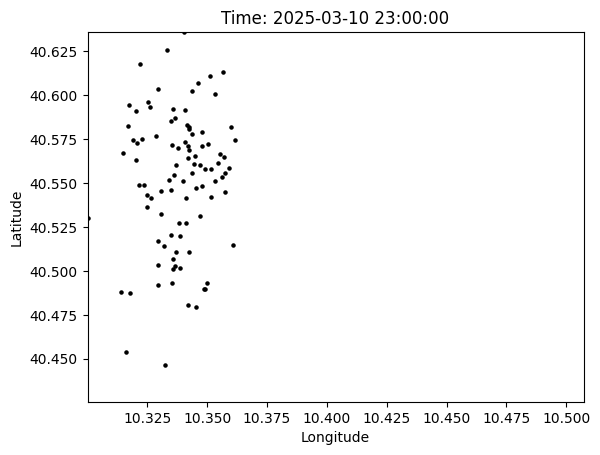

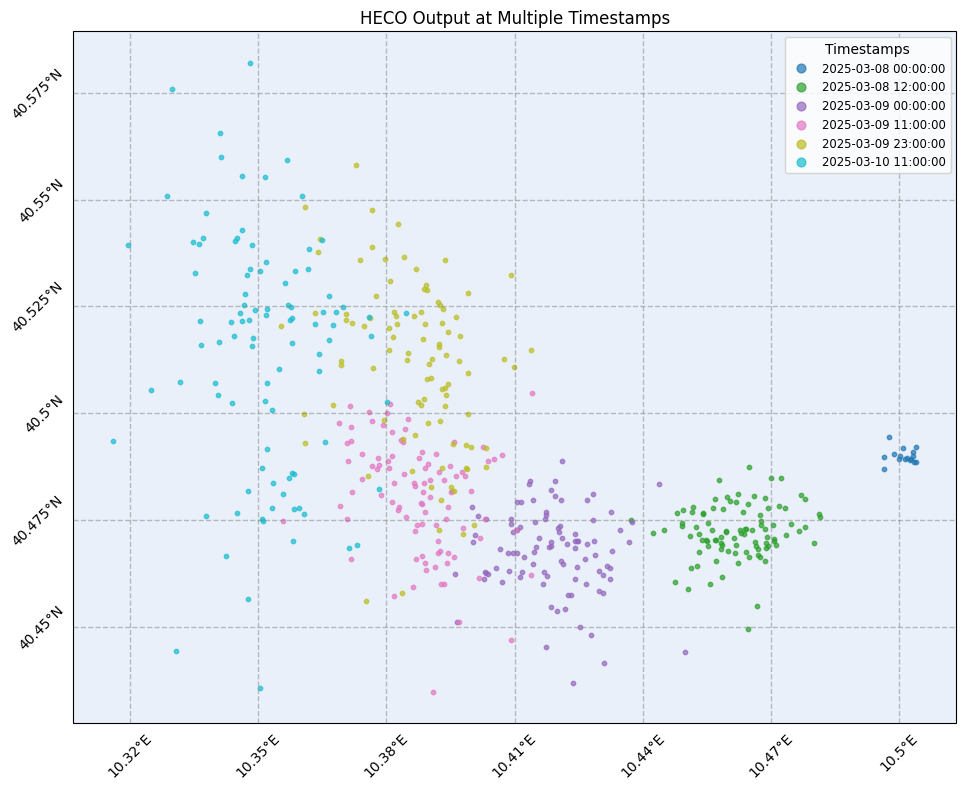

Dataset HECO_TEST.nc opened
Volume per particle considered: 10.0 m3
discrete spill step 0 , release time 2025-03-08 00:00:00
discrete spill step 1 , release time 2025-03-08 01:00:00
discrete spill step 2 , release time 2025-03-08 02:00:00
discrete spill step 3 , release time 2025-03-08 03:00:00
discrete spill step 4 , release time 2025-03-08 04:00:00
discrete spill step 5 , release time 2025-03-08 05:00:00
Simulation results for test 2 saved to sa_2_1/heco_results_test_2.csv and sa_2_1/heco_results_test_2.geojson


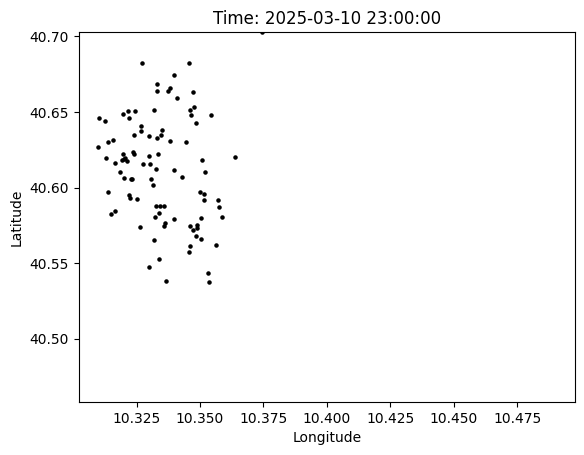

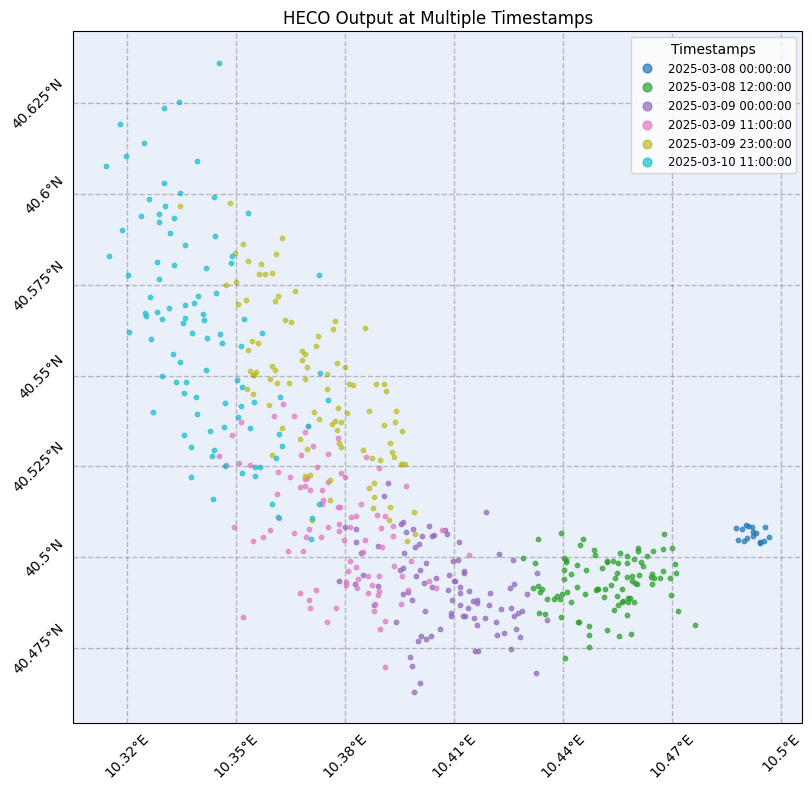

Dataset HECO_TEST.nc opened
Volume per particle considered: 10.0 m3
discrete spill step 0 , release time 2025-03-08 00:00:00
discrete spill step 1 , release time 2025-03-08 01:00:00
discrete spill step 2 , release time 2025-03-08 02:00:00
discrete spill step 3 , release time 2025-03-08 03:00:00
discrete spill step 4 , release time 2025-03-08 04:00:00
discrete spill step 5 , release time 2025-03-08 05:00:00
Simulation results for test 3 saved to sa_2_1/heco_results_test_3.csv and sa_2_1/heco_results_test_3.geojson


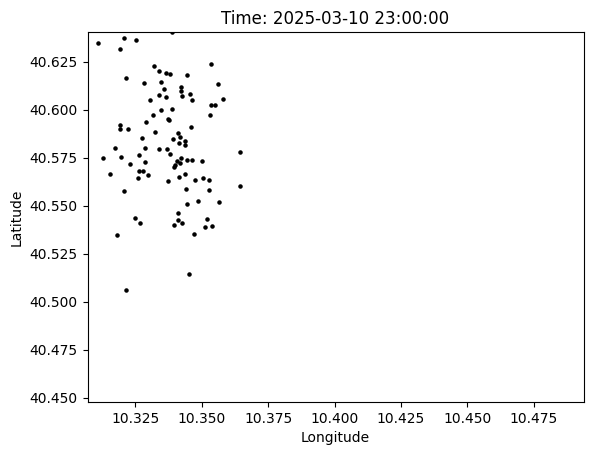

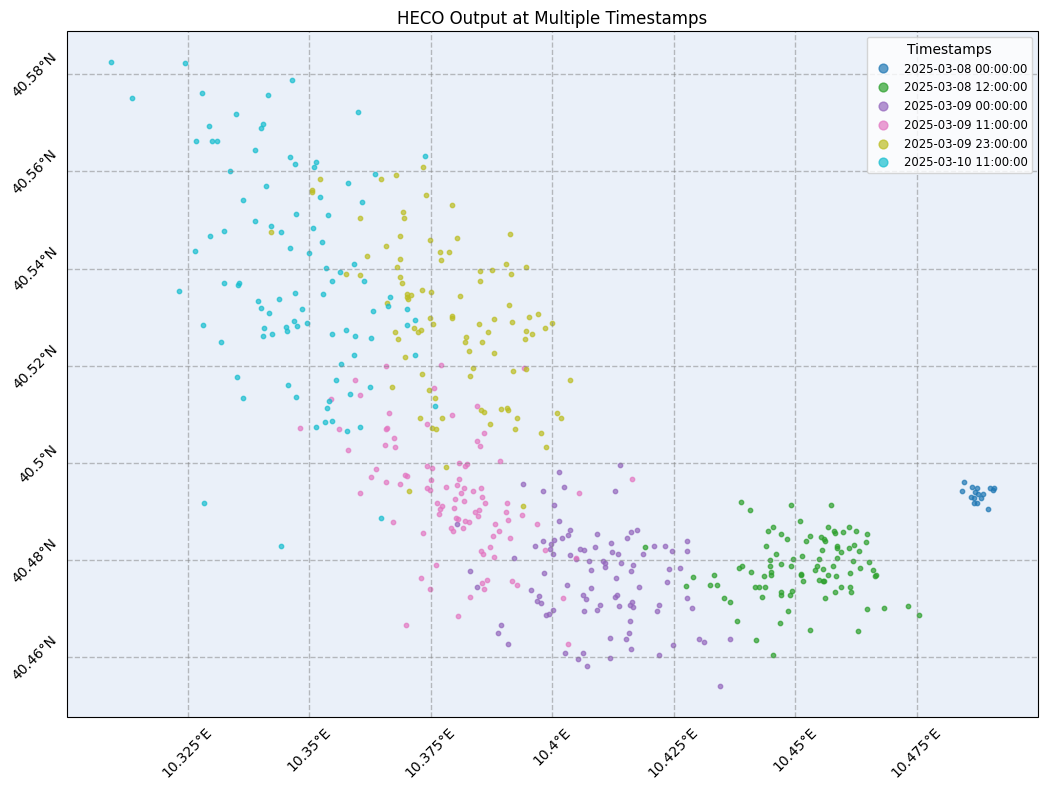

Dataset HECO_TEST.nc opened
Volume per particle considered: 10.0 m3
discrete spill step 0 , release time 2025-03-08 00:00:00
discrete spill step 1 , release time 2025-03-08 01:00:00
discrete spill step 2 , release time 2025-03-08 02:00:00
discrete spill step 3 , release time 2025-03-08 03:00:00
discrete spill step 4 , release time 2025-03-08 04:00:00
discrete spill step 5 , release time 2025-03-08 05:00:00
Simulation results for test 4 saved to sa_2_1/heco_results_test_4.csv and sa_2_1/heco_results_test_4.geojson


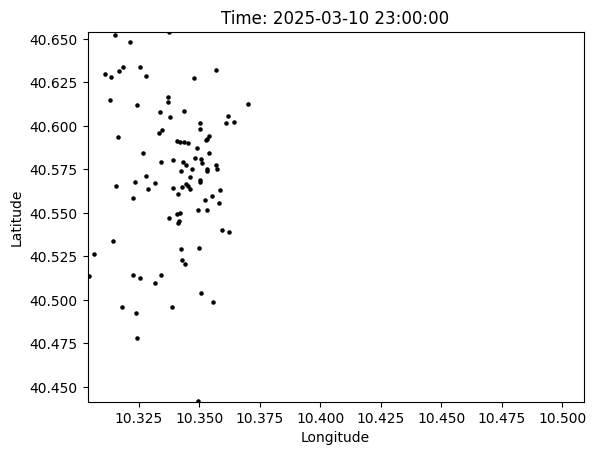

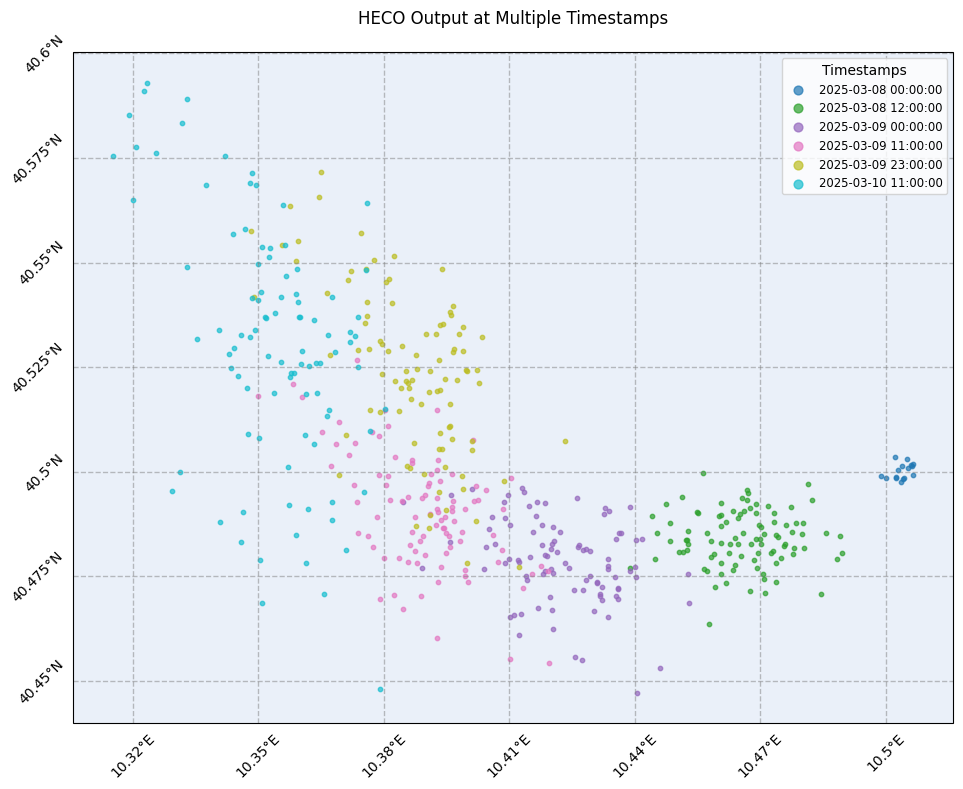

Dataset HECO_TEST.nc opened
Volume per particle considered: 10.0 m3
discrete spill step 0 , release time 2025-03-08 00:00:00
discrete spill step 1 , release time 2025-03-08 01:00:00
discrete spill step 2 , release time 2025-03-08 02:00:00
discrete spill step 3 , release time 2025-03-08 03:00:00
discrete spill step 4 , release time 2025-03-08 04:00:00
discrete spill step 5 , release time 2025-03-08 05:00:00
Simulation results for test 5 saved to sa_2_1/heco_results_test_5.csv and sa_2_1/heco_results_test_5.geojson


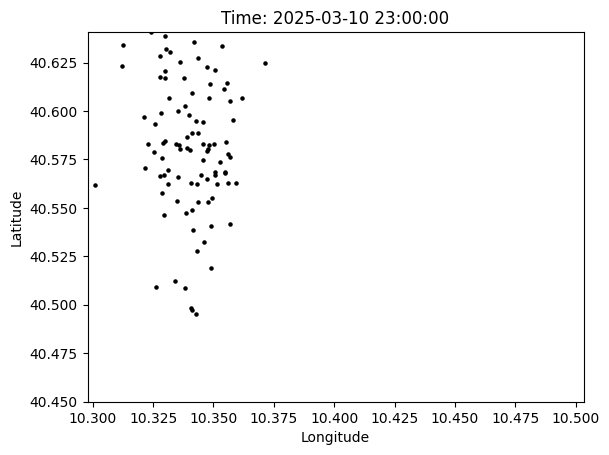

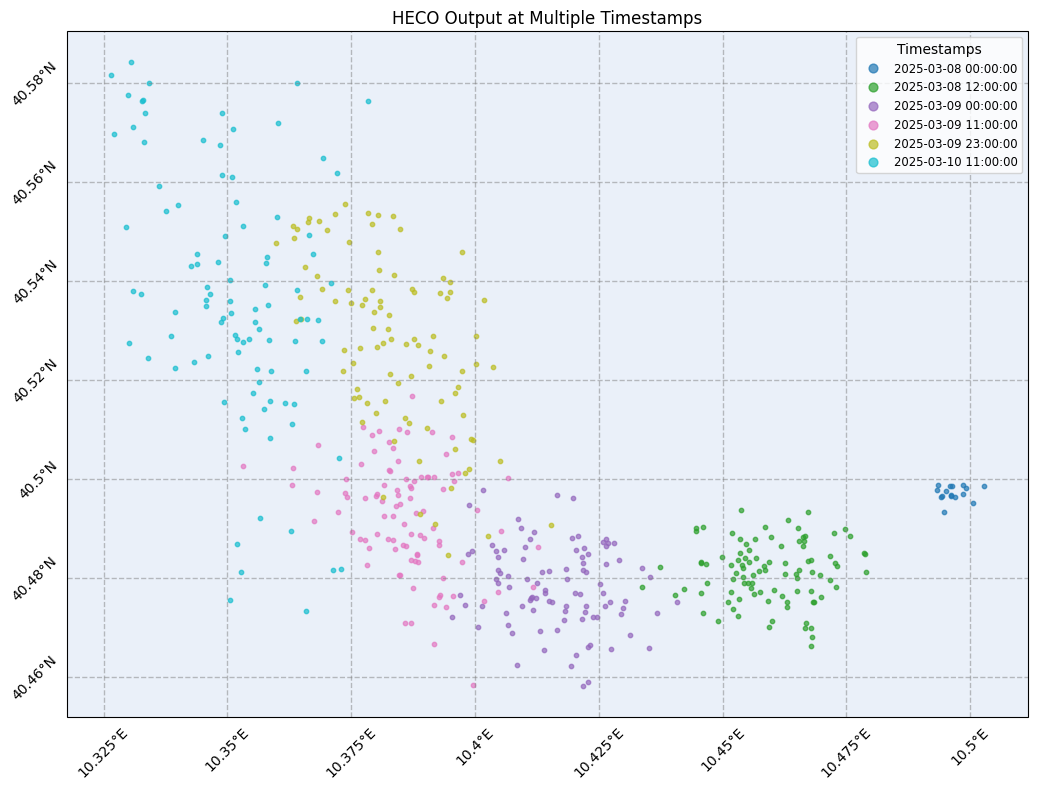

Dataset HECO_TEST.nc opened
Volume per particle considered: 10.0 m3
discrete spill step 0 , release time 2025-03-08 00:00:00
discrete spill step 1 , release time 2025-03-08 01:00:00
discrete spill step 2 , release time 2025-03-08 02:00:00
discrete spill step 3 , release time 2025-03-08 03:00:00
discrete spill step 4 , release time 2025-03-08 04:00:00
discrete spill step 5 , release time 2025-03-08 05:00:00
Simulation results for test 6 saved to sa_2_1/heco_results_test_6.csv and sa_2_1/heco_results_test_6.geojson


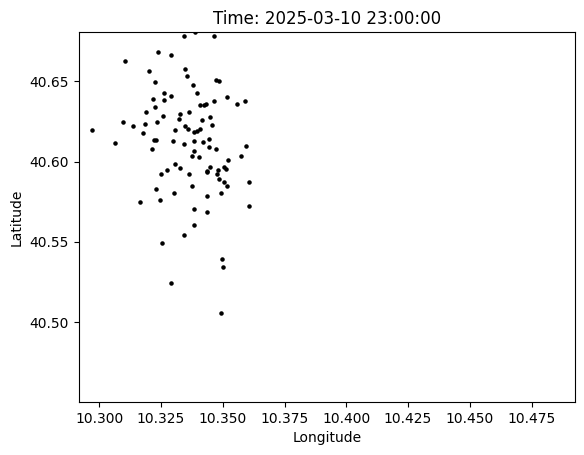

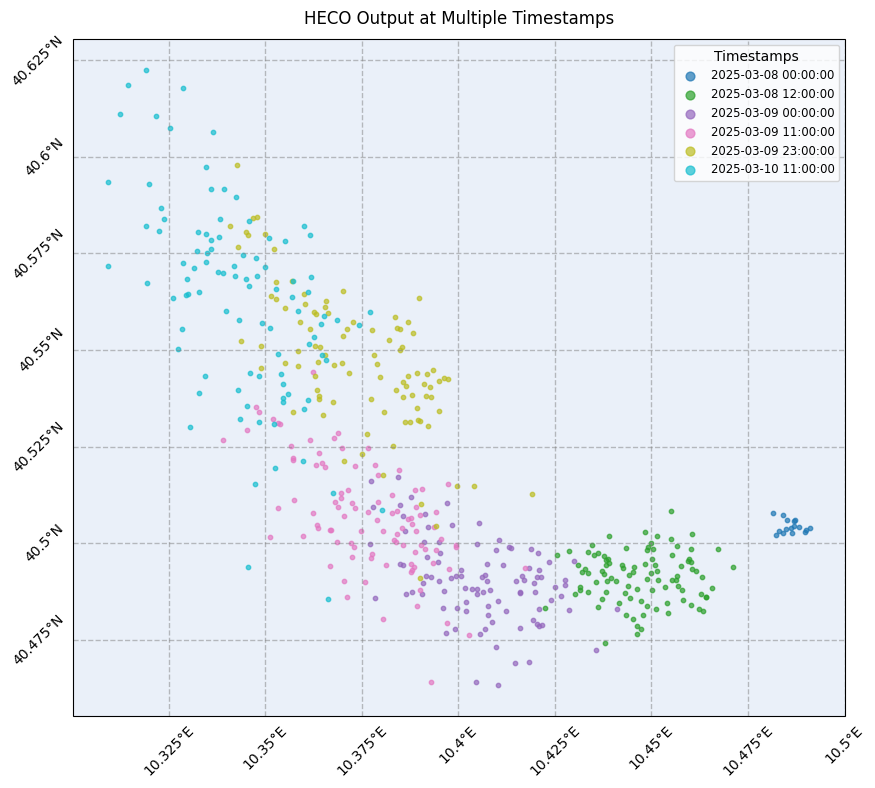

Dataset HECO_TEST.nc opened
Volume per particle considered: 10.0 m3
discrete spill step 0 , release time 2025-03-08 00:00:00
discrete spill step 1 , release time 2025-03-08 01:00:00
discrete spill step 2 , release time 2025-03-08 02:00:00
discrete spill step 3 , release time 2025-03-08 03:00:00
discrete spill step 4 , release time 2025-03-08 04:00:00
discrete spill step 5 , release time 2025-03-08 05:00:00
Simulation results for test 7 saved to sa_2_1/heco_results_test_7.csv and sa_2_1/heco_results_test_7.geojson


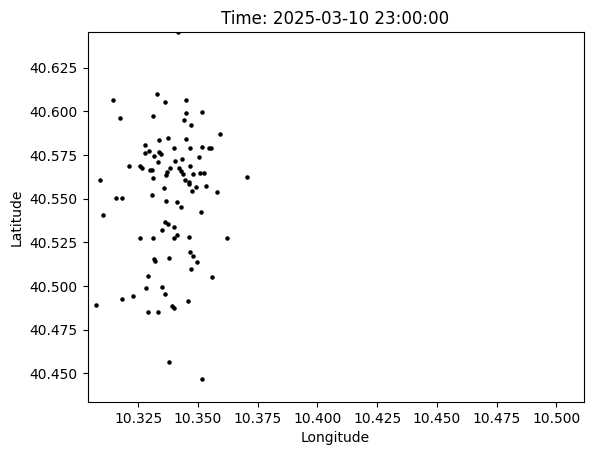

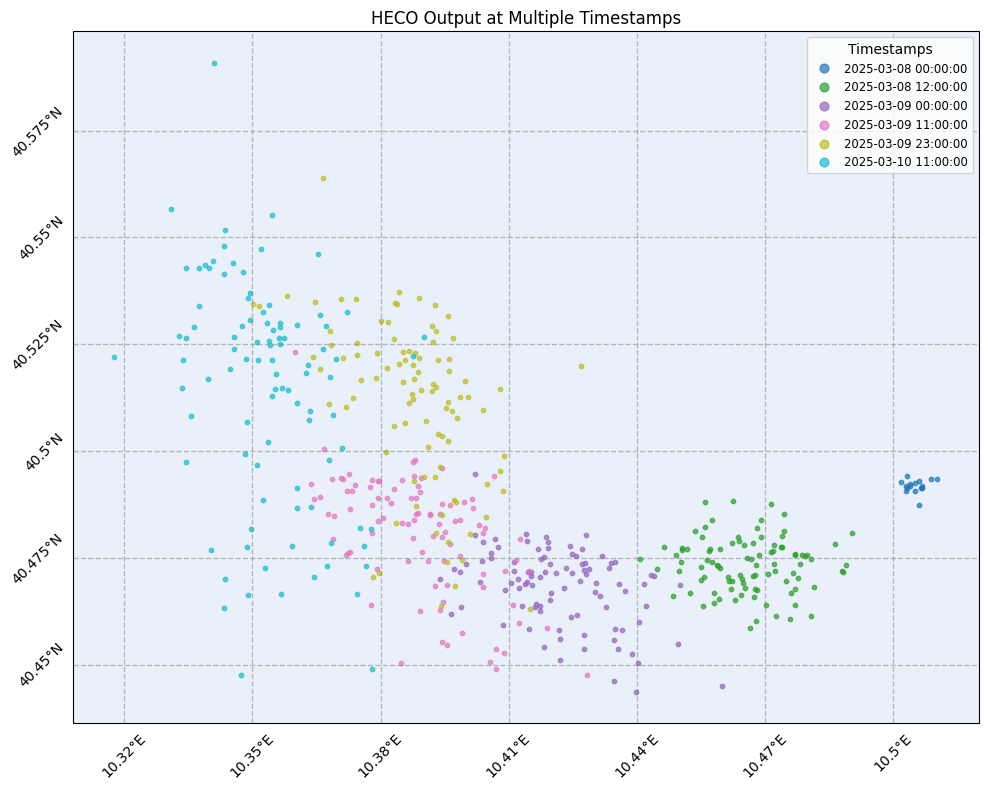

Dataset HECO_TEST.nc opened
Volume per particle considered: 10.0 m3
discrete spill step 0 , release time 2025-03-08 00:00:00
discrete spill step 1 , release time 2025-03-08 01:00:00
discrete spill step 2 , release time 2025-03-08 02:00:00
discrete spill step 3 , release time 2025-03-08 03:00:00
discrete spill step 4 , release time 2025-03-08 04:00:00
discrete spill step 5 , release time 2025-03-08 05:00:00
Simulation results for test 8 saved to sa_2_1/heco_results_test_8.csv and sa_2_1/heco_results_test_8.geojson


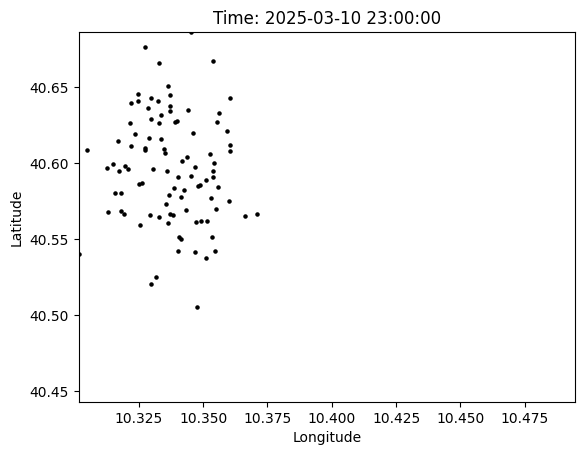

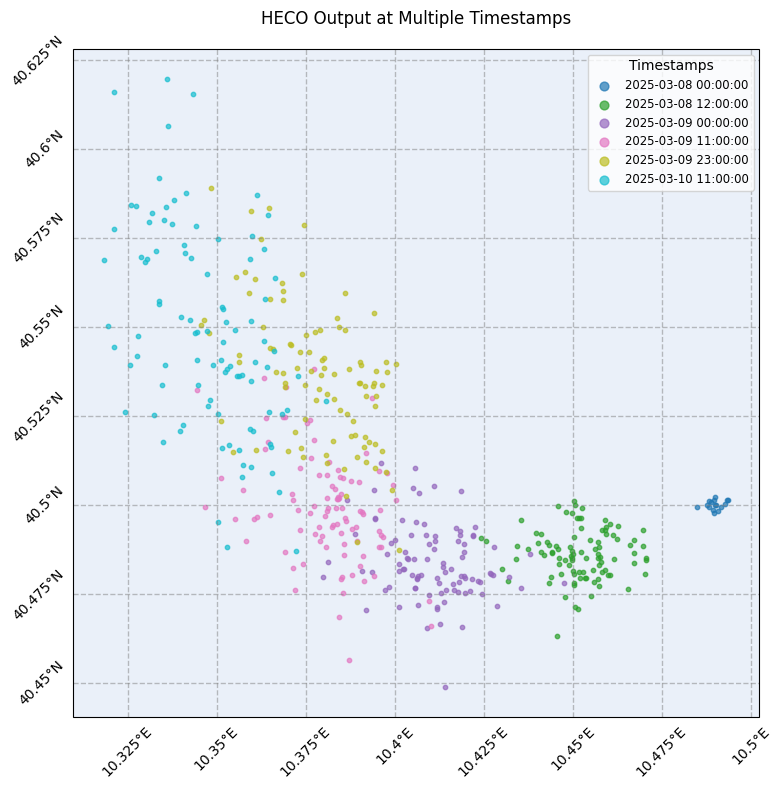

Dataset HECO_TEST.nc opened
Volume per particle considered: 10.0 m3
discrete spill step 0 , release time 2025-03-08 00:00:00
discrete spill step 1 , release time 2025-03-08 01:00:00
discrete spill step 2 , release time 2025-03-08 02:00:00
discrete spill step 3 , release time 2025-03-08 03:00:00
discrete spill step 4 , release time 2025-03-08 04:00:00
discrete spill step 5 , release time 2025-03-08 05:00:00
Simulation results for test 9 saved to sa_2_1/heco_results_test_9.csv and sa_2_1/heco_results_test_9.geojson


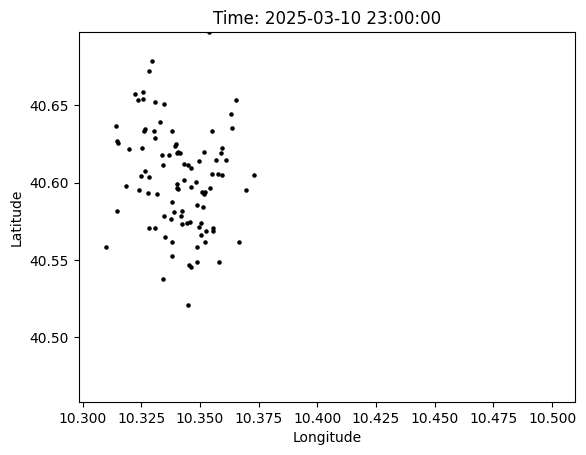

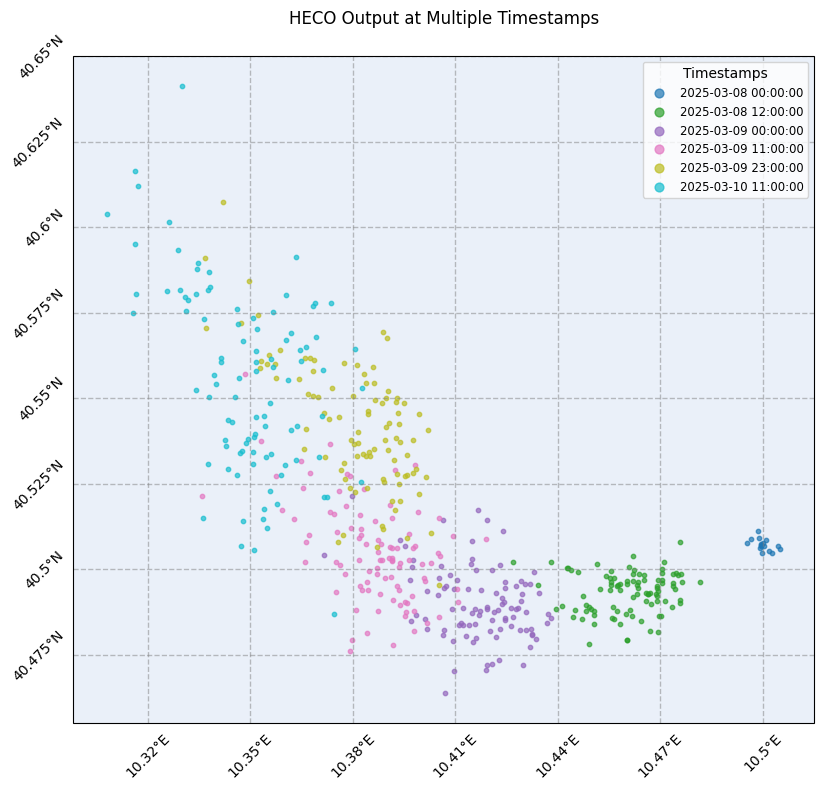

In [7]:
# Run 10 tests generated before

# input config files folder
for i in range(10):
    config_file = f"sa_2_1/sa_2_1_test_{i}.yaml"
    output = heco.run(config_file)
    
    # Save result to csv
    output.to_csv(f'sa_2_1/heco_results_test_{i}.csv', index=False)

    # Save point to geojson with geopandas
    gdf = gpd.GeoDataFrame(output, geometry=gpd.points_from_xy(output.lon, output.lat))
    gdf.crs = "EPSG:4326"
    gdf.to_file(f'sa_2_1/heco_results_test_{i}.geojson', driver='GeoJSON')

    print(f'Simulation results for test {i} saved to sa_2_1/heco_results_test_{i}.csv and sa_2_1/heco_results_test_{i}.geojson')

    heco.create_points_animation(f'sa_2_1/heco_results_test_{i}.geojson',f'sa_2_1/heco_results_test_{i}.gif')
    heco.multitimestamp_plot(output, 6)
    # export webmap

    heco.create_webmap(
        HECOpoint_output_gdf_path = f'sa_2_1/heco_results_test_{i}.geojson',
        EMODnetLayers = True,
        settingsFile_path = config_file,
        output_path = f'sa_2_1/heco_map_test_{i}.html',
        savepolygons = True
    )


### 2.1.1 Results Comparison

In [ ]:
import geopandas as gpd
import os

# create convex hull polygons for each test and compute metrics

def output_points_toconvexhull_polygons(gdf):
    ''' Function that converts points to convex hull polygons
    @param gdf: GeoDataFrame with the data to be converted
    @return: GeoDataFrame with the convex hull polygons
    '''
    gdf['time'] = gdf['time'].astype(str)
    points_time = gdf.dissolve(by='time', as_index=True)
    convex_hull = points_time.convex_hull
    return convex_hull

for i in range(10):
    # open GeoDataFrame
    gdf_path = f'sa_2_1/heco_results_test_{i}.geojson'
    gdf = gpd.read_file(gdf_path) # must contain Points from HECO simulation

    # convert points to convex hull polygons
    convex_hull = output_points_toconvexhull_polygons(gdf)

    # save file
    polygon_output_path = f'sa_2_1/heco_results_test_{i}_polygons.geojson'
    convex_hull.to_file(polygon_output_path, driver='GeoJSON')




In [2]:


import polygons_score
import pandas as pd
import geopandas as gpd

# create table of metrics for each test
metrics_table = pd.DataFrame(columns=['test_id', 'sim_step', 'SRA', 'CI', 'Jaccard', 'DICE'])
obs_path = ('sa_2_1/heco_results_test_0_polygons.geojson')
for i in range(10):
    
    sim_path = (f'sa_2_1/heco_results_test_{i}_polygons.geojson')
    # count the number of feature of the polygons in the observed and simulated files
    obs_count = len(gpd.read_file(obs_path))
    sim_count = len(gpd.read_file(sim_path))
    # conduct file validation test: the number of feature are the same and >0 
    if obs_count > 0 and sim_count > 0 and obs_count == sim_count:
        # compute metrics for each feature
        
        for j in range(obs_count):
            obs_idx = j
            sim_idx = j
            # calculate area of observed and simulated polygons
            obs_area = gpd.read_file(obs_path).iloc[obs_idx].geometry.area
            sim_area = gpd.read_file(sim_path).iloc[sim_idx].geometry.area
            #print(f'Test {i}, Feature {j}: Observed Area={obs_area}, Simulated Area={sim_area}')
            metrics = polygons_score.compute_metrics(
                    obs_path,
                    sim_path,
                    obs_idx=obs_idx,
                    sim_idx=sim_idx,
                    projected_crs="EPSG:32633"
                )
            #print(f'Test {i}, Feature {j}: SRA={metrics["SRA"]}, CI={metrics["CI"]}, Jaccard={metrics["J"]}, DICE={metrics["DICE"]}'    )
            # add metrics data to the table
            metrics_table.loc[-1] = [i, j, metrics['SRA'], metrics['CI'], metrics['J'], metrics['DICE']]
            metrics_table.index = metrics_table.index + 1  # shifting index

# save metrics table to csv
metrics_table.to_csv(f'sa_2_1/heco_results_test_polygons_metrics.csv', index=False)

In [3]:
# calculate the distance of lon0,lat0 of each test from the master test (test 0) and add it to the metrics table
# convert latitude and langitude into UTM before calculating the distance

import math
import geopandas as gpd

master_test_path = 'sa_2_1/heco_results_test_0_polygons.geojson'
master_test = gpd.read_file(master_test_path)
master_lon = master_test.iloc[0].geometry.centroid.x
master_lat = master_test.iloc[0].geometry.centroid.y
# convert lon,lat into UTM, x,y
master_utm = gpd.GeoSeries([gpd.points_from_xy([master_lon], [master_lat])[0]], crs="EPSG:4326").to_crs("EPSG:32636")
master_x = master_utm.x[0]
master_y = master_utm.y[0]

for i in range(10):
    test_path = f'sa_2_1/heco_results_test_{i}_polygons.geojson'
    test = gpd.read_file(test_path)
    test_lon = test.iloc[0].geometry.centroid.x
    test_lat = test.iloc[0].geometry.centroid.y
    # convert lon,lat into UTM, x,y
    test_utm = gpd.GeoSeries([gpd.points_from_xy([test_lon], [test_lat])[0]], crs="EPSG:4326").to_crs("EPSG:32636")
    test_x = test_utm.x[0]
    test_y = test_utm.y[0]
    
    distance = math.hypot(test_x - master_x, test_y - master_y)
    metrics_table.loc[metrics_table['test_id'] == i, 'origin_perturbation'] = distance


metrics_table.to_csv(f'sa_2_1/heco_results_test_polygons_metrics.csv', index=False)

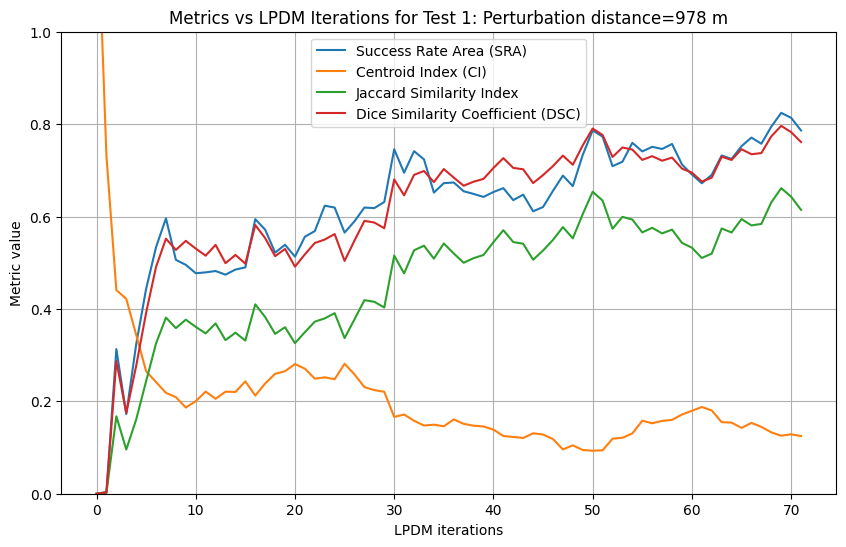

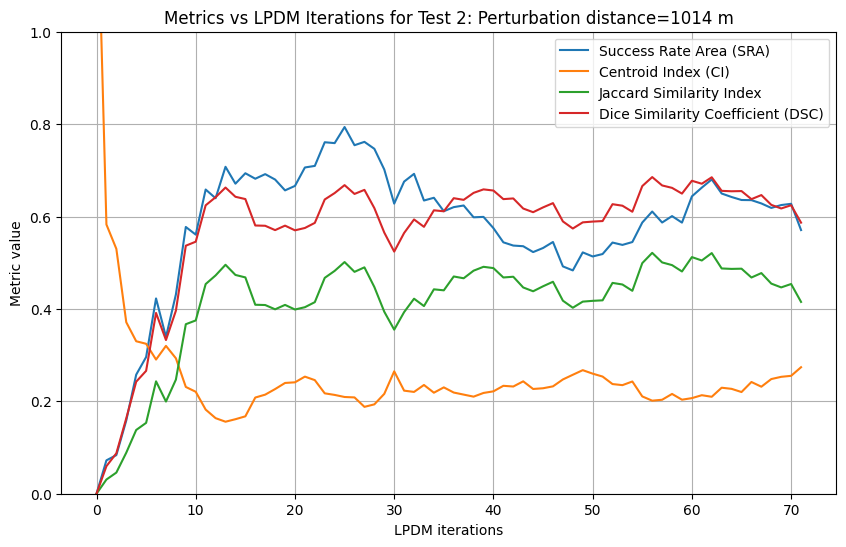

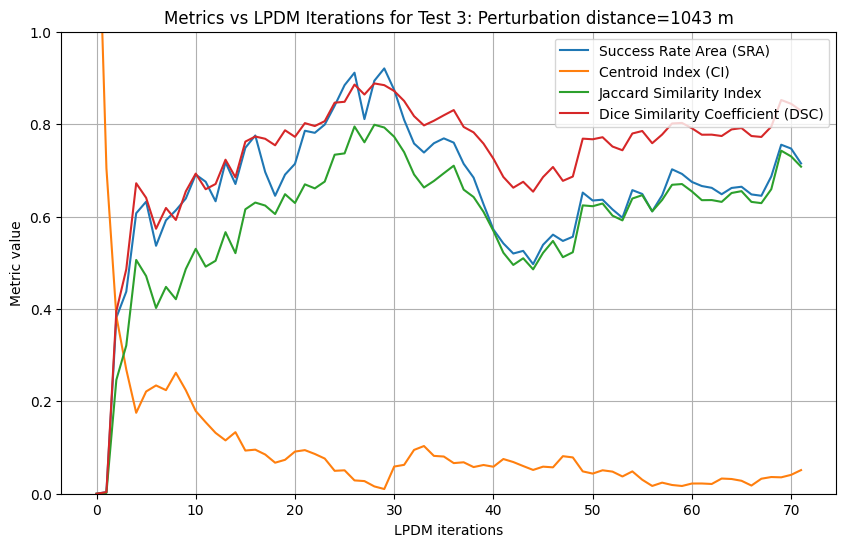

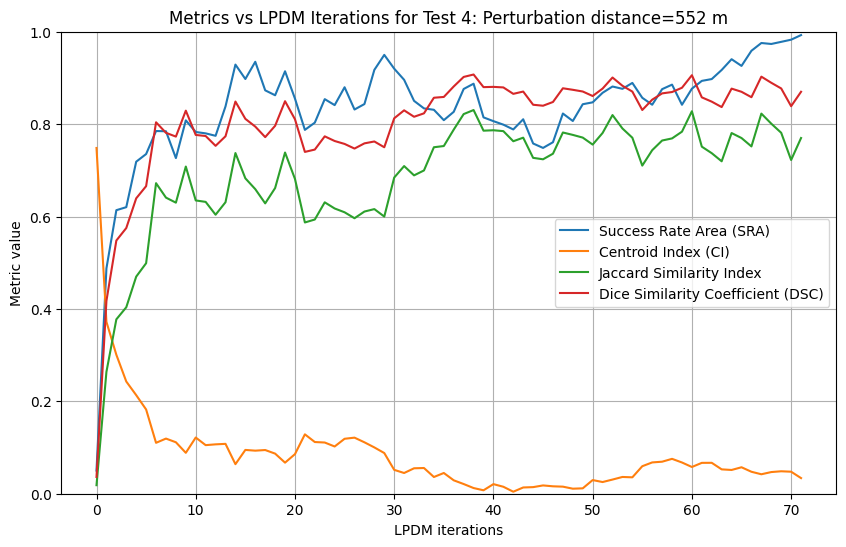

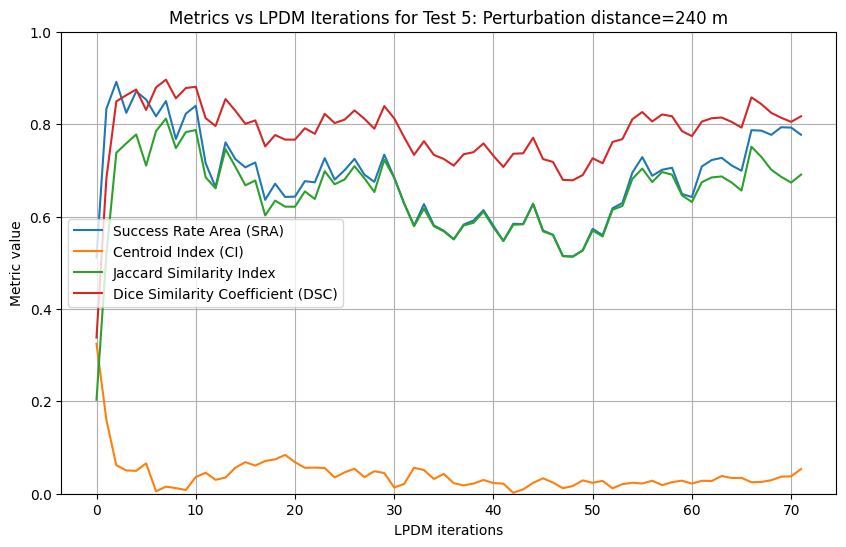

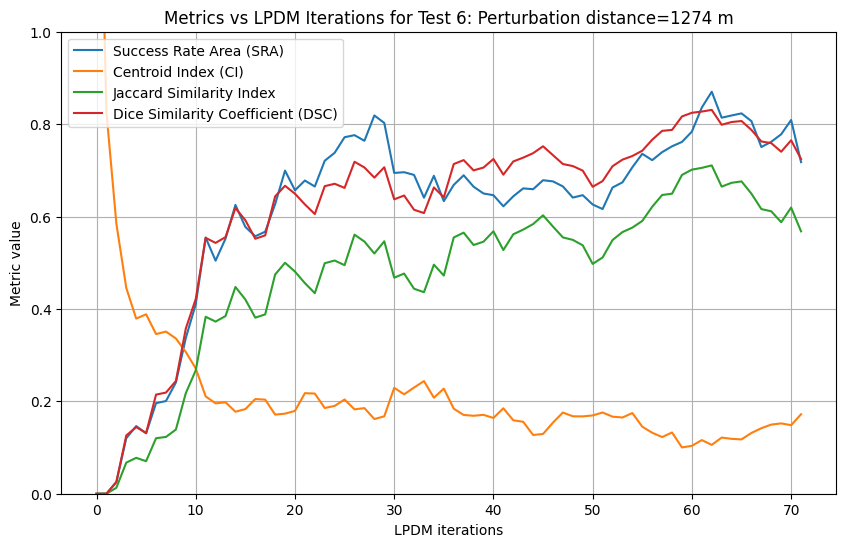

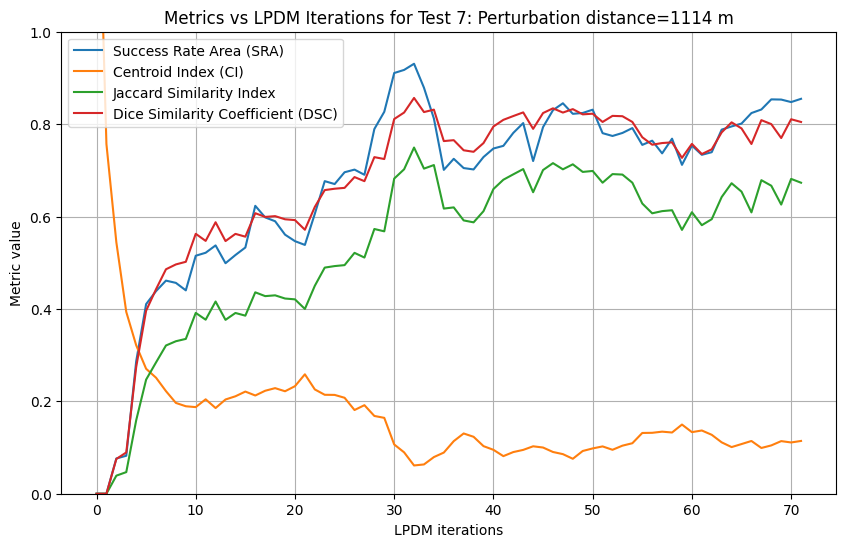

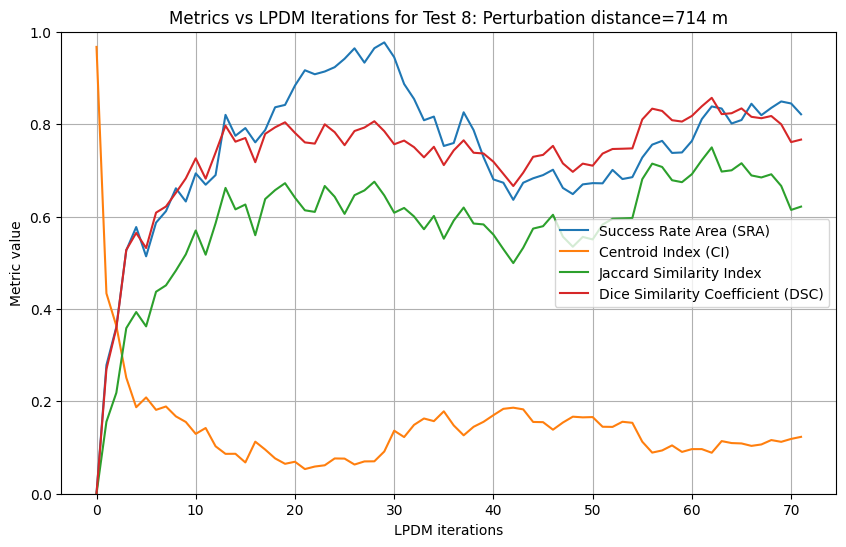

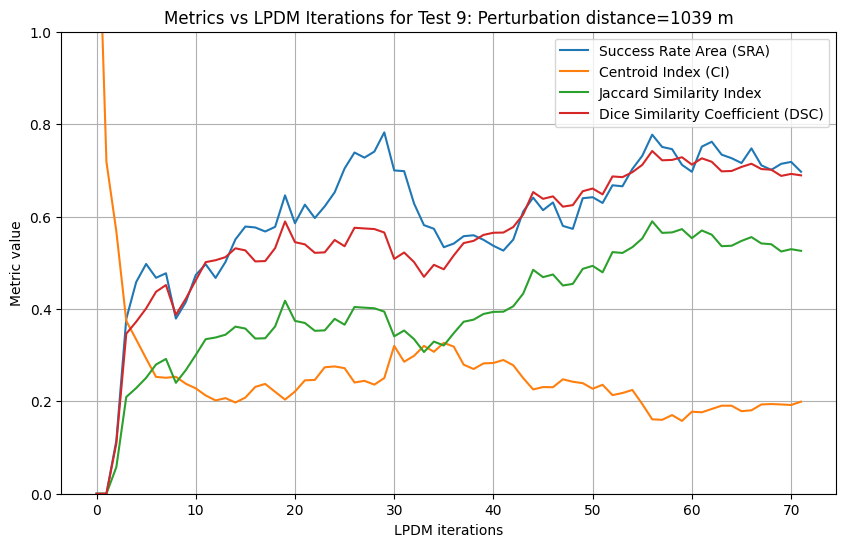

In [4]:
# plot diagrams of metrics_table
import matplotlib.pyplot as plt
import pandas as pd
# import csv file into pandas dataframe
metrics_table = pd.read_csv(f'sa_2_1/heco_results_test_polygons_metrics.csv')

test_id_latest = metrics_table['test_id'].max()
test_id_latest = int(test_id_latest)
for i in range(test_id_latest + 1):
    if i == 0: continue # skip the master test
    plt.figure(figsize=(10, 6))
    plt.title(f'Metrics vs LPDM Iterations for Test {i}: Perturbation distance={metrics_table[metrics_table["test_id"] == i]["origin_perturbation"].iloc[0]:.0f} m')
    plt.xlabel('LPDM iterations')
    plt.ylabel('Metric value')
    plt.plot(metrics_table[metrics_table['test_id'] == i]['sim_step'], metrics_table[metrics_table['test_id'] == i]['SRA'], label='Success Rate Area (SRA)')
    plt.plot(metrics_table[metrics_table['test_id'] == i]['sim_step'], metrics_table[metrics_table['test_id'] == i]['CI'], label='Centroid Index (CI)')
    plt.plot(metrics_table[metrics_table['test_id'] == i]['sim_step'], metrics_table[metrics_table['test_id'] == i]['Jaccard'], label='Jaccard Similarity Index')
    plt.plot(metrics_table[metrics_table['test_id'] == i]['sim_step'], metrics_table[metrics_table['test_id'] == i]['DICE'], label='Dice Similarity Coefficient (DSC)')
    plt.legend()
    plt.ylim(0, 1)
    plt.grid()
    plt.savefig(f'sa_2_1/metrics_vs_lpdm_iterations_test_{i}.png')
    plt.show()




In [5]:
# ── Pretty printer last iterations data────────────────────────────────────────────────────────────
 
import pandas as pd

def print_report(m: dict) -> None:
    SEP = "─" * 80
    print(SEP)
    print(f"  Test ID: {m['test_id']}, LPDM iteration: {m['sim_step']}, Perturbation distance: {m['origin_perturbation']:.0f} m")
    print(SEP)
    print(f"  Success Rate Area      (SRA) : {m['SRA']:>10.4f}   [0–1,  higher ↑ = better]")
    print(f"  Centroid Index          (CI) : {m['CI']:>10.4f}   [≥ 0,  lower  ↓ = better]")
    print(f"  Jaccard Similarity Index (J) : {m['Jaccard']:>10.4f}   [0–1,  higher ↑ = better]")
    print(f"  Dice Similarity Coeff. (DSC) : {m['DICE']:>10.4f}   [0–1,  higher ↑ = better]")
    print(SEP)

# import csv file into pandas dataframe
metrics_table = pd.read_csv(f'sa_2_1/heco_results_test_polygons_metrics.csv')
# sort by perturbation distance
metrics_table = metrics_table.sort_values(by=['origin_perturbation'], ascending=[True])
test_id_latest = metrics_table['test_id'].max()
test_id_latest = int(test_id_latest)

# create dataframe with the last iteration metrics for each test_id
metrics_last_iteration = pd.DataFrame(columns=['test_id', 'sim_step', 'SRA', 'CI', 'Jaccard', 'DICE', 'origin_perturbation'])

for i in range(1, 10):
    # prepare the test_id value
    test_id = i
    # subset metrics_table for the current test_id
    metrics_subset = metrics_table[metrics_table['test_id'] == test_id]
    # get the last iteration metrics for the current test_id
    sim_step_max = metrics_subset['sim_step'].max()
    sim_step_max = int(sim_step_max)

    metric_to_print = metrics_subset[metrics_subset['sim_step'] == sim_step_max].iloc[0].to_dict()
    print_report(metric_to_print)

    # append the metrics to the dataframe
    metrics_last_iteration.loc[len(metrics_last_iteration)] = [metric_to_print['test_id'], metric_to_print['sim_step'], metric_to_print['SRA'], metric_to_print['CI'], metric_to_print['Jaccard'], metric_to_print['DICE'], metric_to_print['origin_perturbation']]

# save last iteration metrics to csv
metrics_last_iteration.to_csv(f'sa_2_1/heco_results_test_polygons_metrics_last_iteration.csv', index=False)

────────────────────────────────────────────────────────────────────────────────
  Test ID: 1.0, LPDM iteration: 71.0, Perturbation distance: 978 m
────────────────────────────────────────────────────────────────────────────────
  Success Rate Area      (SRA) :     0.7862   [0–1,  higher ↑ = better]
  Centroid Index          (CI) :     0.1248   [≥ 0,  lower  ↓ = better]
  Jaccard Similarity Index (J) :     0.6144   [0–1,  higher ↑ = better]
  Dice Similarity Coeff. (DSC) :     0.7612   [0–1,  higher ↑ = better]
────────────────────────────────────────────────────────────────────────────────
────────────────────────────────────────────────────────────────────────────────
  Test ID: 2.0, LPDM iteration: 71.0, Perturbation distance: 1014 m
────────────────────────────────────────────────────────────────────────────────
  Success Rate Area      (SRA) :     0.5707   [0–1,  higher ↑ = better]
  Centroid Index          (CI) :     0.2738   [≥ 0,  lower  ↓ = better]
  Jaccard Similarity Index (

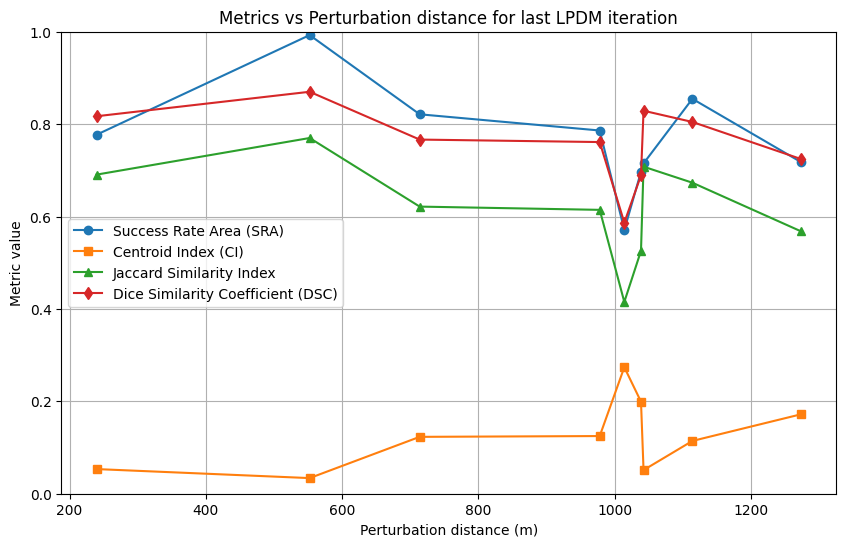

In [6]:
# plot diagrams of metrics_last_iteration
#sort by perturbation distance
metrics_last_iteration = metrics_last_iteration.sort_values(by=['origin_perturbation'], ascending=[True])

plt.figure(figsize=(10, 6))
plt.title(f'Metrics vs Perturbation distance for last LPDM iteration')
plt.xlabel('Perturbation distance (m)')
plt.ylabel('Metric value')
plt.plot(metrics_last_iteration['origin_perturbation'], metrics_last_iteration['SRA'], marker='o', label='Success Rate Area (SRA)')
plt.plot(metrics_last_iteration['origin_perturbation'], metrics_last_iteration['CI'], marker='s', label='Centroid Index (CI)')
plt.plot(metrics_last_iteration['origin_perturbation'], metrics_last_iteration['Jaccard'], marker='^', label='Jaccard Similarity Index')
plt.plot(metrics_last_iteration['origin_perturbation'], metrics_last_iteration['DICE'], marker='d', label='Dice Similarity Coefficient (DSC)')
plt.legend()
plt.ylim(0, 1)
plt.grid()
plt.savefig(f'sa_2_1/metrics_vs_origin_perturbation_last_iteration.png')
plt.show()

